In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# TOP_STOCKS = ["NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "ASML"]
STOCKS = ['AAPL', 'TSLA', 'MSFT']
OUTPUT_PATH = Path("/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs")

train_data = joblib.load(OUTPUT_PATH /'train_data.joblib')
test_data = joblib.load(OUTPUT_PATH /'test_data.joblib')

AAPL: PROPHET -> MAE: 28.4060, RMSE: 33.9633


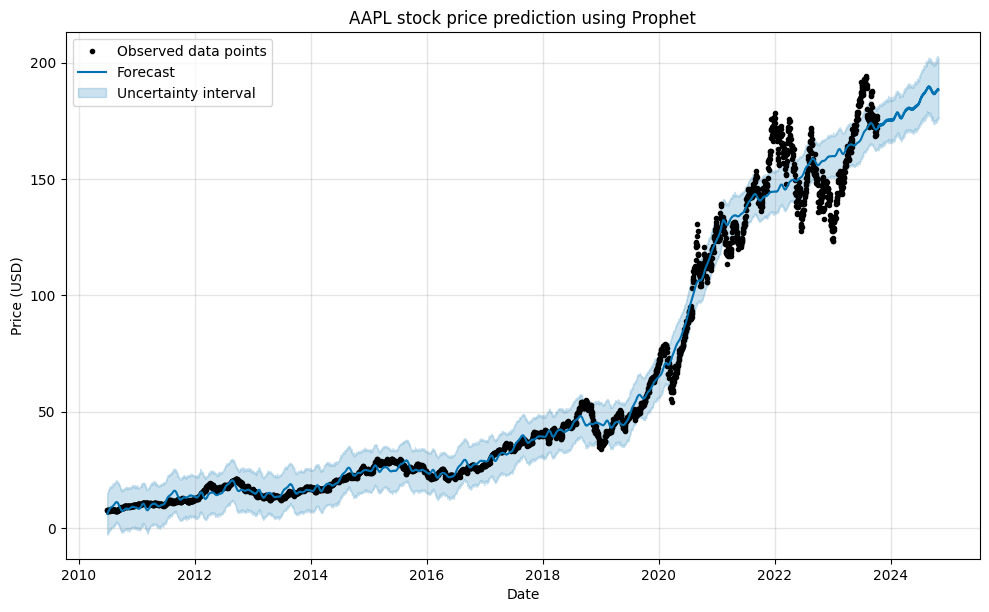

TSLA: PROPHET -> MAE: 56.8173, RMSE: 82.0118


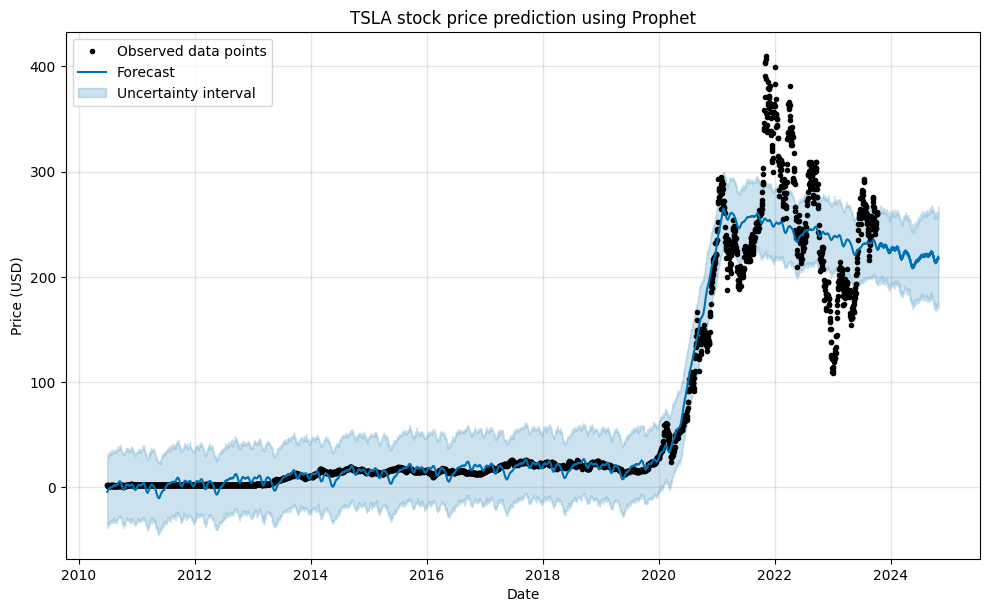

MSFT: PROPHET -> MAE: 94.8415, RMSE: 98.0576


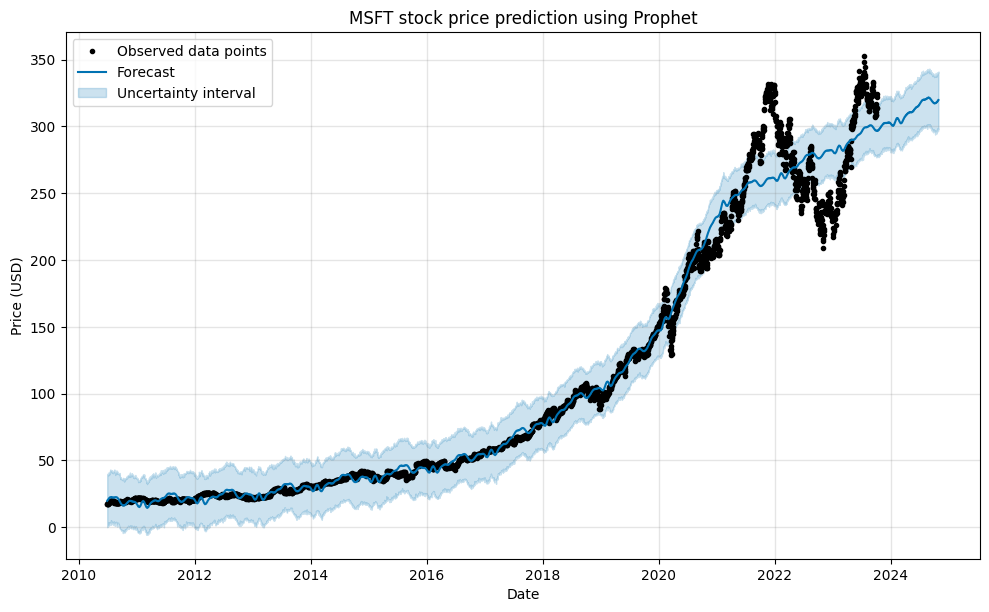

In [4]:
model_prophet = {}

for stock in STOCKS:
    try:
        df_train = train_data[stock].copy().reset_index().rename(columns={'index': 'ds', stock: 'y'})
        df_test = test_data[stock].copy().reset_index().rename(columns={'index': 'ds', stock: 'y'})

        model = Prophet(daily_seasonality=False)
        model.fit(df_train)
        future = model.make_future_dataframe(periods=len(test_data[stock]))
        forecast = model.predict(future)
        y_pred = forecast['yhat'].tail(len(test_data[stock])).values
        y_test = test_data[stock].values
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"{stock}: PROPHET -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        model.plot(forecast)
        plt.title(f'{stock} stock price prediction using Prophet')
        plt.xlabel('Date')
        plt.ylabel('Price (USD)')
        plt.legend()
        plt.show()

        model_prophet[stock] = {
            "model_object": model,
            "y_pred": y_pred,
            "y_test": y_test,
            "y_test_index": test_data[stock].index,
            "forecast": forecast,
            "metrics": {"mae": round(mae, 4), "rmse": round(rmse, 4)}
        }

    except Exception as e:
        print(f"Failed {stock}: {e}")
        continue

In [5]:
model_prophet_tuned = {}
changepoint_scales = [0.01, 0.05, 0.1, 0.5]
seasonality_scales = [1, 5, 10, 20]

for stock in STOCKS:
    try:
        df_train = train_data[stock].copy().reset_index().rename(columns={"index": "ds", stock: "y"})
        df_test = test_data[stock].copy().reset_index().rename(columns={"index": "ds", stock: "y"})
        actual_prices = df_test['y'].values
        best_rmse = float("inf")
        best_data = {}

        print(f"\n--- Tuning {stock} ---")

        for cp_scale in changepoint_scales:
            for s_scale in seasonality_scales:
                model = Prophet(
                    changepoint_prior_scale=cp_scale,
                    seasonality_prior_scale=s_scale,
                    daily_seasonality=False
                )
                model.fit(df_train)
                future = model.make_future_dataframe(periods=len(df_test))
                forecast = model.predict(future)
                y_pred = forecast["yhat"].tail(len(df_test)).values
                mae = mean_absolute_error(actual_prices, y_pred)
                rmse = np.sqrt(mean_squared_error(actual_prices, y_pred))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_data = {
                        "model_object": model,
                        "y_pred": y_pred,
                        "params": {"cp": cp_scale, "season": s_scale},
                        "mae": mae,
                    }
        best_y_pred = best_data["y_pred"]
        print(f"WINNER -> {stock}: Params: {best_data['params']}, MAE: {best_data['mae']:.4f}")

        model_prophet_tuned[stock] = {
            "model_object": best_data["model_object"],
            "y_pred": best_y_pred,
            "y_test": actual_prices,
            "y_test_index": df_test['ds'].values,
            "forecast": forecast,
            "metrics": {"mae": round(best_data['mae'], 4), "rmse": round(best_rmse, 4)},
            "best_params": best_data["params"]
        }

    except Exception as e:
        print(f"Error tuning {stock}: {e}")
        continue


--- Tuning AAPL ---
WINNER -> AAPL: Params: {'cp': 0.01, 'season': 20}, MAE: 24.7750

--- Tuning TSLA ---
WINNER -> TSLA: Params: {'cp': 0.01, 'season': 5}, MAE: 60.6669

--- Tuning MSFT ---
WINNER -> MSFT: Params: {'cp': 0.01, 'season': 20}, MAE: 84.8011


AAPL: PROPHET with hyperparameters -> Params: {'cp': 0.01, 'season': 20},  MAE: 24.775, RMSE: 29.8922


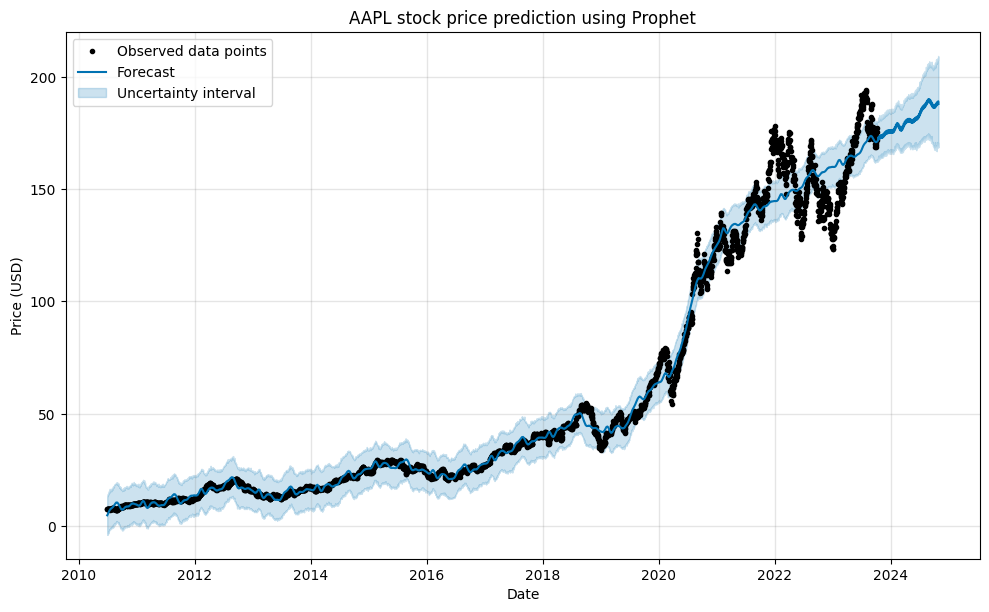

TSLA: PROPHET with hyperparameters -> Params: {'cp': 0.01, 'season': 5},  MAE: 60.6669, RMSE: 73.639


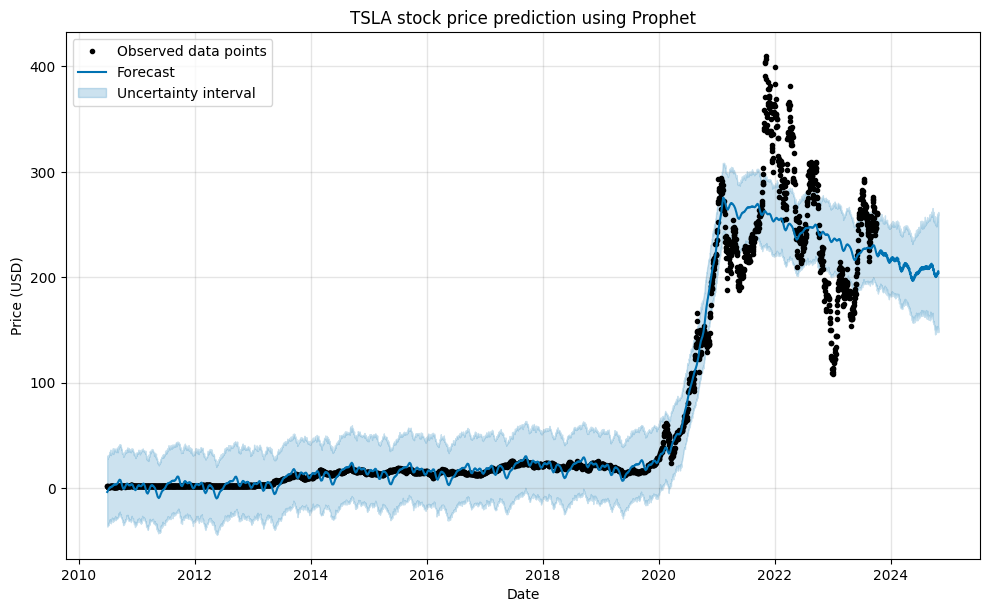

MSFT: PROPHET with hyperparameters -> Params: {'cp': 0.01, 'season': 20},  MAE: 84.8011, RMSE: 88.2391


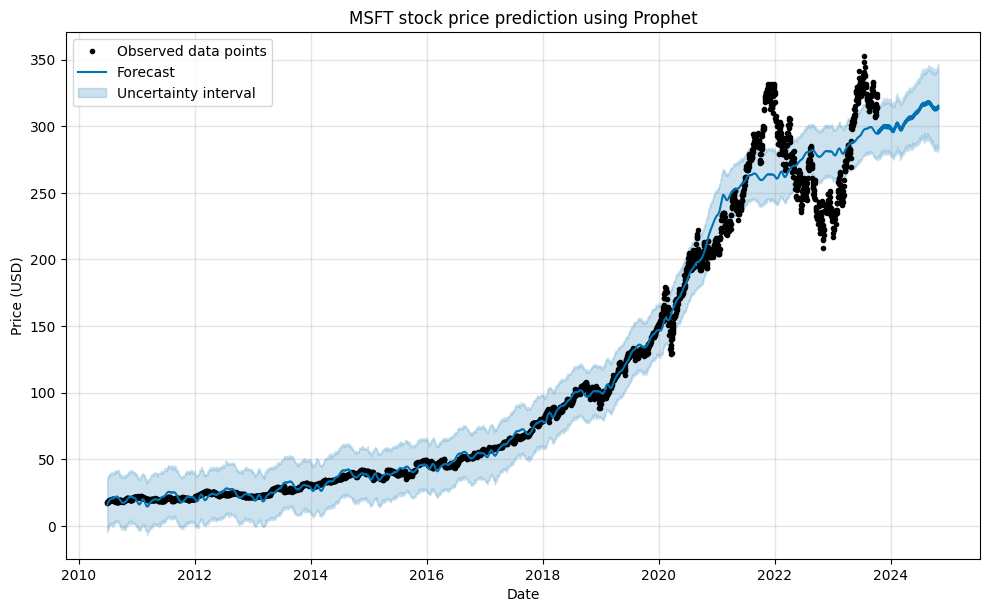

In [6]:
# plot results for the turned prophet models
for stock in STOCKS:
    model = model_prophet_tuned[stock]
    print(f"{stock}: PROPHET with hyperparameters -> Params: {model['best_params']},  MAE: {model['metrics']['mae']}, RMSE: {model['metrics']['rmse']}")
    model['model_object'].plot(model['forecast'])
    plt.title(f'{stock} stock price prediction using Prophet')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

In [7]:
# Save results
joblib.dump(model_prophet, OUTPUT_PATH / "models/model_prophet.joblib")
joblib.dump(model_prophet_tuned, OUTPUT_PATH / "models/model_prophet_tuned.joblib")

['/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs/models/model_prophet_tuned.joblib']